#  Very First ML Project

## **Load Data**

In [ ]:
import pandas as pd #importing python library | pd=alias for Python Library

df  = pd.read_csv('https://raw.githubusercontent.com/dataprofessor/data/refs/heads/master/delaney_solubility_with_descriptors.csv') #error when not raw native file. the pd. is the alias given from the import on line 1
df # df = shorthand for data frame variable (is this a convention?). loads tabular (rows, columns, headers, cells) data from the .read_csv file

,MolLogP,MolWt,NumRotatableBonds,AromaticProportion,logS
0,2.59540,167.850,0.0,0.000000,-2.180
1,2.37650,133.405,0.0,0.000000,-2.000
2,2.59380,167.850,1.0,0.000000,-1.740
3,2.02890,133.405,1.0,0.000000,-1.480
4,2.91890,187.375,1.0,0.000000,-3.040
...,...,...,...,...,...
1139,1.98820,287.343,8.0,0.000000,1.144
1140,3.42130,286.114,2.0,0.333333,-4.925
1141,3.60960,308.333,4.0,0.695652,-3.893
1142,2.56214,354.815,3.0,0.521739,-3.790


##  **Data Prep**

### ***

***

In [ ]:
df.columns

Index(['MolLogP', 'MolWt', 'NumRotatableBonds', 'AromaticProportion'], dtype='object')

In [ ]:
y = df['logS']
y

,logS
0,-2.180
1,-2.000
2,-1.740
3,-1.480
4,-3.040
...,...
1139,1.144
1140,-4.925
1141,-3.893
1142,-3.790


In [ ]:
x = df.drop('logS', axis=1) #drops the logS value from the columns. if axis = 0, it drops rows.
x #dropped the logS column w/ calling x!

,MolLogP,MolWt,NumRotatableBonds,AromaticProportion
0,2.59540,167.850,0.0,0.000000
1,2.37650,133.405,0.0,0.000000
2,2.59380,167.850,1.0,0.000000
3,2.02890,133.405,1.0,0.000000
4,2.91890,187.375,1.0,0.000000
...,...,...,...,...
1139,1.98820,287.343,8.0,0.000000
1140,3.42130,286.114,2.0,0.333333
1141,3.60960,308.333,4.0,0.695652
1142,2.56214,354.815,3.0,0.521739


### **Data Splitting**

In [ ]:
from sklearn.model_selection import train_test_split #importing from .model.selection submodule (apart of sklearn, or scikit-learn library). This is popular for ML. splits data from training and testing set with that last bit.

x_test, x_train, y_test, y_train = train_test_split(x, y, test_size=0.2, random_state=100) #test_size means 20% of my data = testing sets | the remaining .80 will be used for training.

x_test, x_train, y_test, y_train # the 20-30% range is just enough testing data for the training model to learn.
#reproducibility = the random_state= allows the same shuffling pattern to be the same for the random numbers. If it was different, it'll produce different data.

(     MolLogP    MolWt  NumRotatableBonds  AromaticProportion
 107  3.14280  112.216                5.0            0.000000
 378 -2.07850  142.070                0.0            0.000000
 529 -0.47730  168.152                0.0            0.000000
 546 -0.86740  154.125                0.0            0.000000
 320  1.62150  100.161                2.0            0.000000
 ..       ...      ...                ...                 ...
 802  3.00254  250.301                1.0            0.842105
 53   2.13860   82.146                3.0            0.000000
 350  5.76304  256.348                0.0            0.900000
 79   3.89960  186.339               10.0            0.000000
 792  2.52334  310.297                3.0            0.300000
 
 [915 rows x 4 columns],
       MolLogP    MolWt  NumRotatableBonds  AromaticProportion
 822   2.91000  172.268                7.0            0.000000
 118   7.27400  360.882                1.0            0.666667
 347   1.94040  145.161                0

## Model Build

### Linear Regression


*Training the Linear Regression (Model)

In [ ]:
from sklearn.linear_model import LinearRegression #imports functions and help with building linear regression models | a model = math function that represents-or models-your data *aka linear regression, neural networks, etc.

lr = LinearRegression() #lr = shorthand for linear regression variable
lr.fit(x_train,  y_train) #learn the line of best fit from the training data

LinearRegression()

Making Predictions with this model

---



In [ ]:
y_lr_train_pred = lr.predict(x_train) #predictions = based on the x-training data, it's predicting the best value for y. the convention: y_lr_train_pred is good for separating different models
y_lr_test_pred = lr.predict(x_test) #predicts the x-test variables for best y results.

print(y_lr_train_pred) #comma separates both values | better than separate print statements. #separating them to see values (20% train, 80% test)

[ -2.80523836  -7.84725926  -2.44512908  -1.9614752   -1.94082503
  -0.88090184  -0.4524243   -0.45926574  -5.69172021  -3.8839056
  -3.86648246  -2.18005532  -1.35152747  -1.31610127  -4.6965455
  -1.78164001  -1.45168091  -3.00550701  -3.68466326  -5.64740086
  -3.18128246  -4.9778282   -5.68576173  -1.99485812  -4.11999068
  -5.09634503  -3.03302324  -4.4505163   -4.21319399   0.6673196
  -1.28703322  -4.50644406  -2.3851764   -1.4610778   -0.40982329
  -1.57773882  -2.610201    -3.20340302  -5.07729237  -1.61169498
  -1.40904576  -1.88841376  -6.61781791  -8.19598131  -5.73184498
  -4.15262718  -3.50794021   1.49477779   0.09161104  -2.24110426
  -1.73830665  -5.09634503   1.01280815  -3.03235458  -5.17198177
  -1.88646418  -7.84725926  -1.03181999  -0.83000647  -4.9778282
  -2.34198969  -2.79524469  -2.50796129  -2.10896812  -1.50775928
  -1.36904086  -3.17349361  -2.63889225  -1.77363172  -3.09538668
  -3.34449089  -0.79891672  -4.73818882  -0.65094211  -7.35349299
 -10.74189577 

**Evaluate Performance of the Model**

In [ ]:
from sklearn.metrics  import mean_squared_error, r2_score #from the sklearn.metrics library, we're determining the coefficient of determination |  this is basically relating the x-values determine the behavior of y. MSE = predictions close to true values is good; if MSE is too far from true values, that's not a good model

lr_train_mse = mean_squared_error(y_train, y_lr_train_pred) #MSE=(y-true values - y-pred values)^2
lr_train_r2 = r2_score(y_train, y_lr_train_pred) #coefficient of determination | high=captures variation well, low=guessing variation, negative=misleading variation results

In [ ]:
from sklearn.metrics  import mean_squared_error, r2_score
lr_test_mse = mean_squared_error(y_test, y_lr_test_pred) #same as training data functions
lr_test_r2 = r2_score(y_test, y_lr_test_pred)

In [ ]:
print('LR MSE (Train): ', lr_train_mse) #cleaner print functions for all test and train data for MSE and R2
print('LR R2 (Train): ', lr_train_r2) #comprised instead of separated print functions
print('LR MSE (Test): ', lr_test_mse)
print('LR R2 (Test): ', lr_test_r2)

LR MSE (Train):  1.0059495483447636
LR R2 (Train):  0.792207566202151
LR MSE (Test):  1.0238726072807542
LR R2 (Test):  0.7606868366737254


In [ ]:
lr_results = pd.DataFrame(['Linear regression', lr_train_mse, lr_train_r2, lr_test_mse, lr_test_r2]).transpose() #transpose() flips your tabular data vertically instead of horizontally

lr_results.columns = ['Method', 'Training MSE', 'Training R2', 'Test MSE', 'Test R2'] #naming the columns

In [ ]:
lr_results

,Method,Training MSE,Training R2,Test MSE,Test R2
0,Linear regression,1.00595,0.792208,1.023873,0.760687


### Random Forest Model

**Training the Model**

In [ ]:
from sklearn.ensemble import RandomForestRegressor #since all of our data is numerical (integers & floats), it's regression models = line of continuous values (Francis Galton and children's heights compared to their parents)

rf = RandomForestRegressor(max_depth=2, random_state=100) #max_depth = longest path from the tree's root(first decision point) to a leaf (final decision) } will stop at nodes 2, the second split from the decision tree
rf.fit(x_train, y_train) #training the model

RandomForestRegressor(max_depth=2, random_state=100)

In [ ]:
y_rf_train_pred = rf.predict(x_train) #predictions = based on the x-training data, it's predicting the best value for y. the convention: y_lr_train_pred is good for separating different models
y_rf_test_pred = rf.predict(x_test) #predicts the x-test variables for best y results.


In [ ]:
from sklearn.metrics  import mean_squared_error, r2_score #from the sklearn.metrics library, we're determining the coefficient of determination |  this is basically relating the x-values determine the behavior of y. MSE = predictions close to true values is good; if MSE is too far from true values, that's not a good model

rf_train_mse = mean_squared_error(y_train, y_rf_train_pred) #MSE=(y-true values - y-pred values)^2
rf_train_r2 = r2_score(y_train, y_rf_train_pred) #coefficient of determination | high=captures variation well, low=guessing variation, negative=misleading variation results

rf_test_mse = mean_squared_error(y_test, y_rf_test_pred)
rf_test_r2 = r2_score(y_test, y_rf_test_pred)


In [ ]:
rf_results = pd.DataFrame(['Random Forest ', rf_train_mse, rf_train_r2, rf_test_mse, rf_test_r2]).transpose() #transpose() flips your tabular data vertically instead of horizontally

rf_results.columns = ['Method', 'Training MSE', 'Training R2', 'Test MSE', 'Test R2'] #naming the columns
rf_results

,Method,Training MSE,Training R2,Test MSE,Test R2
0,Random Forest,1.056472,0.781771,1.157941,0.729351


### LR and RF Comparison

In [ ]:
import pandas as pd

# Re-defining metric variables with their last known values
lr_train_mse = 1.0059495483447636
lr_train_r2 = 0.792207566202151
lr_test_mse = 1.0238726072807542
lr_test_r2 = 0.7606868366737254

rf_train_mse = 1.056472
rf_train_r2 = 0.781771
rf_test_mse = 1.157941
rf_test_r2 = 0.729351

# Re-defining lr_results
lr_results = pd.DataFrame(['Linear regression', lr_train_mse, lr_train_r2, lr_test_mse, lr_test_r2]).transpose()
lr_results.columns = ['Method', 'Training MSE', 'Training R2', 'Test MSE', 'Test R2']

# Re-defining rf_results
rf_results = pd.DataFrame(['Random Forest ', rf_train_mse, rf_train_r2, rf_test_mse, rf_test_r2]).transpose()
rf_results.columns = ['Method', 'Training MSE', 'Training R2', 'Test MSE', 'Test R2']

df_models = pd.concat([lr_results, rf_results], axis=1).reset_index() #.pd.concat() combine pandas objects like DataFrames *haven't done Series yet | List of data frames to add together. axis=0 (row)
df_models

,index,Method,Training MSE,Training R2,Test MSE,Test R2,Method,Training MSE,Training R2,Test MSE,Test R2
0,0,Linear regression,1.00595,0.792208,1.023873,0.760687,Random Forest,1.056472,0.781771,1.157941,0.729351


# Data Visualization w/ Prediction Results


Text(0.5, 1.0, 'Linear Regression Model')

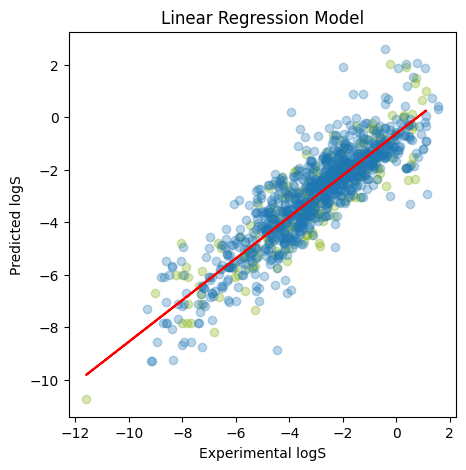

In [ ]:
import matplotlib.pyplot as plt #importing python library | plt=alias for Python Library
import numpy as np

plt.figure(figsize=(5,5)) #size of the graph
plt.scatter(x=y_train, y=y_lr_train_pred, c='#7CAE05', alpha=0.3) #.scatter plot for x training data (y_train) & y(predictable data) | alpha = transparency (RGBA), or color scheme for pixels (picture elements); range is from 0 (opaque) to 1 (invisible)

plt.scatter(x=y_test, y=y_lr_test_pred, alpha=0.3) #.scatter plot for x testing data (y_test) & y(predictable data)

z = np.polyfit(y_train, y_lr_train_pred, 1) #represents best fit line with np.polyfit = stands for polynomial curve | polynomial means a variable raied to a power that's then multiplied added together
p = np.poly1d(z) # Corrected to use 'z' (coefficients from polyfit)

plt.plot(y_train, p(y_train), color='red') # Plot the line of best fit for training data

plt.xlabel('Experimental logS') #x-axis label
plt.ylabel('Predicted logS') #y-axis label
plt.title('Linear Regression Model') #title of the graph